# Universal Data Augmentation Colab
# Domains: Image, Video, Text, Tabular, Timeseries, Speech, Document

In [1]:
# Install dependencies
!pip install albumentations==1.3.0 nlpaug tsaug moviepy torchaudio tensorflow tensorflow_datasets pydub imbalanced-learn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 15.3 MB/s eta 0:00:00


# IMAGE AUGMENTATION

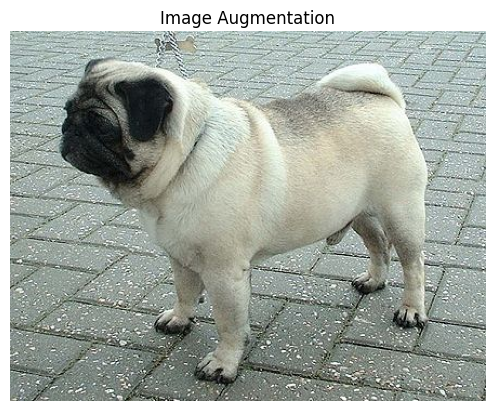

In [9]:
# -----------------------------
# 📸 IMAGE AUGMENTATION (Albumentations)
# -----------------------------
import albumentations as A
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Load image using requests
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/9/9a/Pug_600.jpg/440px-Pug_600.jpg"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
image = Image.open(BytesIO(response.content)).convert("RGB")

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
])
augmented_image = transform(image=np.array(image))["image"]

plt.imshow(augmented_image)
plt.title("Image Augmentation")
plt.axis("off")
plt.show()

<ipython-input-13-d5692335f185>:20: UserWarning: Argument(s) 'scale_min, scale_max' are not valid for transform Downscale
  A.Downscale(scale_min=0.3, scale_max=0.5, p=0.3),


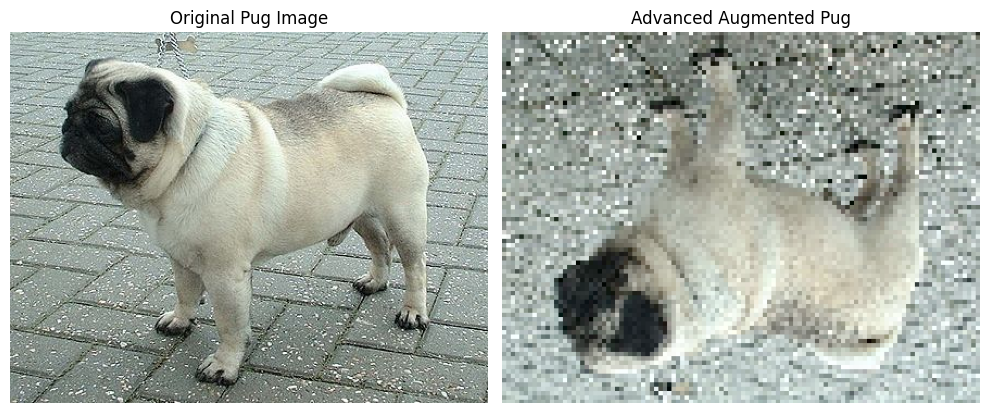

In [13]:
import albumentations as A
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Load image using requests
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/9/9a/Pug_600.jpg/440px-Pug_600.jpg"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
image = Image.open(BytesIO(response.content)).convert("RGB")

# Additional downward augmentation examples
transform = A.Compose([
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.RandomGamma(p=0.3),
    A.Perspective(scale=(0.05, 0.1), p=0.3),
    A.Downscale(scale_min=0.3, scale_max=0.5, p=0.3),
])

augmented_image = transform(image=np.array(image))["image"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Pug Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title("Advanced Augmented Pug")
plt.axis("off")
plt.tight_layout()
plt.show()

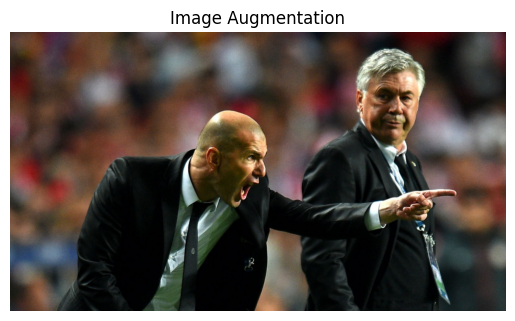

In [11]:
import albumentations as A
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Load image using requests
url = "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
image = Image.open(BytesIO(response.content)).convert("RGB")

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
])
augmented_image = transform(image=np.array(image))["image"]

plt.imshow(augmented_image)
plt.title("Image Augmentation")
plt.axis("off")
plt.show()

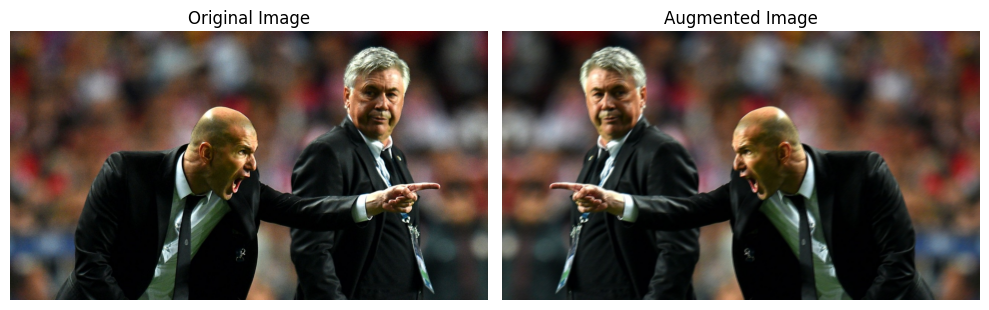

In [12]:
import albumentations as A
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Load image using requests
url = "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
image = Image.open(BytesIO(response.content)).convert("RGB")

# Multiple augmentations
augmentations = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Rotate(limit=25, p=0.3),
    A.CLAHE(p=0.2),
    A.MotionBlur(p=0.2),
    A.RandomShadow(p=0.2),
    A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.3)
])

augmented_image = augmentations(image=np.array(image))["image"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title("Augmented Image")
plt.axis("off")
plt.tight_layout()
plt.show()

# VIDEO AUGMENTATION (MoviePy)

In [14]:
# -----------------------------
# 🎬 VIDEO AUGMENTATION (MoviePy)
# -----------------------------
import moviepy.editor as mpy
print("Simulated video augmentation with MoviePy: mpy.vfx.mirror_x")

  if event.key is 'enter':



Simulated video augmentation with MoviePy: mpy.vfx.mirror_x


Original duration: 3 sec
Augmented duration: 3 sec
Moviepy - Building video /tmp/augmented_video.mp4.
MoviePy - Writing audio in augmented_videoTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video /tmp/augmented_video.mp4



Moviepy - Done !
Moviepy - video ready /tmp/augmented_video.mp4


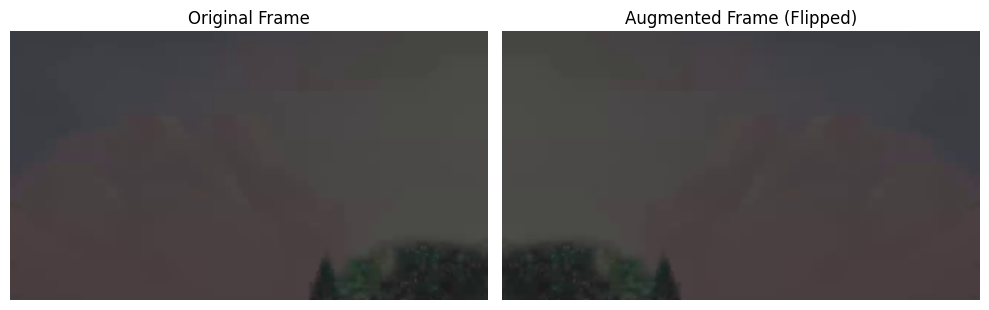

In [16]:
import moviepy.editor as mpy
import os

# Download a short video for testing
# Updated URL
video_url = "https://github.com/mediaelement/mediaelement-files/blob/master/big_buck_bunny.mp4?raw=true"
video_path = "/tmp/input_video.mp4"
output_path = "/tmp/augmented_video.mp4"
if not os.path.exists(video_path):
    import urllib.request
    urllib.request.urlretrieve(video_url, video_path)

# Load video clip
clip = mpy.VideoFileClip(video_path).subclip(0, 3)  # use only first 3 seconds to be safe

# Apply augmentation - horizontal flip
augmented_clip = clip.fx(mpy.vfx.mirror_x)

# Display info before saving
print("Original duration:", clip.duration, "sec")
print("Augmented duration:", augmented_clip.duration, "sec")

# Write to file and preview one frame
augmented_clip.write_videofile(output_path, codec="libx264", audio_codec="aac")

# Show thumbnail comparison
frame_original = clip.get_frame(1)  # get frame at 1 sec
frame_aug = augmented_clip.get_frame(1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(frame_original)
plt.title("Original Frame")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(frame_aug)
plt.title("Augmented Frame (Flipped)")
plt.axis("off")
plt.tight_layout()
plt.show()

# TEXT AUGMENTATION (nlpaug or augly.text)

In [17]:
# -----------------------------
# 📝 TEXT (nlpaug or augly.text)
# -----------------------------
import augly.text as txtaugs

text = "Data augmentation is powerful"
aug_text = txtaugs.InsertPunctuationChars()(text)
print("\nOriginal:", text)
print("Augmented:", aug_text)


Original: Data augmentation is powerful
Augmented: ["D'a't'a' 'a'u'g'm'e'n't'a't'i'o'n' 'i's' 'p'o'w'e'r'f'u'l"]



Original: The quick brown fox jumps over the lazy dog.
OCR Augmentation: ['The quick brown fox jumps uvek the lazy dog.']
Keyboard Augmentation: ['The quivU brown fox jumps ovRg the Kaz% dog.']
Insert Augmentation: ['The quick brown fox jtu)mps o6vVer the 4l*azy dog.']
Substitute Augmentation: ['The !uicU OroTn fox jumps over the laY4 dog.']
Swap Augmentation: ['The quick bowrn fox jumps over the lazy dog.']
Delete Augmentation: ['The qic brown fox jumps er the az dog.']



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(aug_counts.keys()), y=list(aug_counts.values()), palette="viridis")



[Skipped] BERT-based augmentation (transformers not installed)


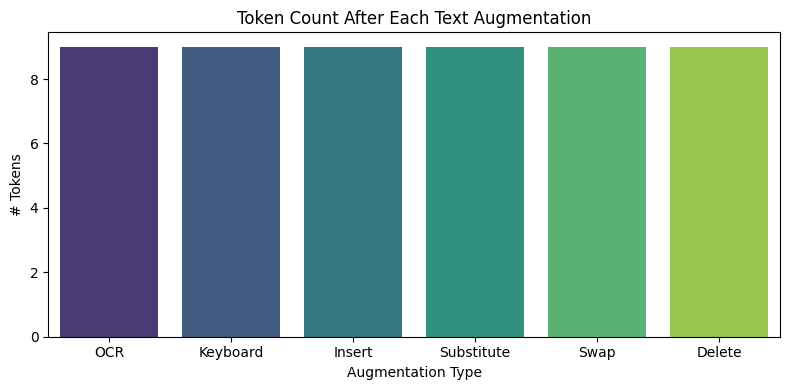

OCR Augmentation: ['The quick brown fox jumps over the lazy du9.']
Keyboard Augmentation: ['The quick brpwM fox jum9A over the lzz6 dog.']
Insert Augmentation: ['The Mquieck brXo0wn fox jumps over the vlazBy dog.']
Substitute Augmentation: ['The euicz prown fox jumps ovC! the lazy dog.']
Swap Augmentation: ['The uqcik brown fox jusmp over the zlay dog.']
Delete Augmentation: ['The qui brn fox jumps oe the lazy dog.']



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(aug_counts.keys()), y=list(aug_counts.values()), palette="viridis")



[Skipped] BERT-based augmentation (transformers not installed)


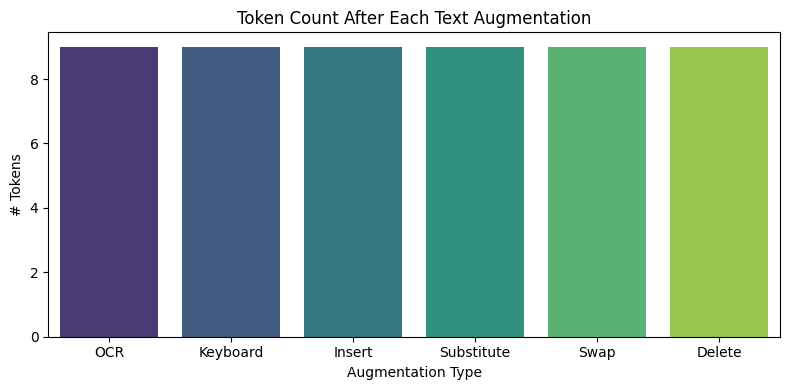

In [24]:
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.sentence as nas
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nlpaug.augmenter.char as nac
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.sentence as nas
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

text = 'The quick brown fox jumps over the lazy dog.'

print("\nOriginal:", text)

augmenters = {
    "OCR": nac.OcrAug(),
    "Keyboard": nac.KeyboardAug(),
    "Insert": nac.RandomCharAug(action="insert"),
    "Substitute": nac.RandomCharAug(action="substitute"),
    "Swap": nac.RandomCharAug(action="swap"),
    "Delete": nac.RandomCharAug(action="delete")
}

aug_counts = Counter()
aug_texts = {}

for name, aug in augmenters.items():
    aug_result = aug.augment(text)
    aug_texts[name] = aug_result
    aug_counts[name] = len(aug_result.split()) if isinstance(aug_result, str) else len(aug_result[0].split())
    print(f"{name} Augmentation:", aug_result)

# Optional: BERT-based augmentation
try:
    bert_aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute")
    bert_result = bert_aug.augment(text)
    aug_texts["BERT"] = bert_result
    aug_counts["BERT"] = len(bert_result.split())
    print("BERT Substitution Augmentation:", bert_result)
except:
    print("[Skipped] BERT-based augmentation (transformers not installed)")

# Plot token count comparison
plt.figure(figsize=(8, 4))
sns.barplot(x=list(aug_counts.keys()), y=list(aug_counts.values()), palette="viridis")
plt.title("Token Count After Each Text Augmentation")
plt.ylabel("# Tokens")
plt.xlabel("Augmentation Type")
plt.tight_layout()
plt.show()
augmenters = {
    "OCR": nac.OcrAug(),
    "Keyboard": nac.KeyboardAug(),
    "Insert": nac.RandomCharAug(action="insert"),
    "Substitute": nac.RandomCharAug(action="substitute"),
    "Swap": nac.RandomCharAug(action="swap"),
    "Delete": nac.RandomCharAug(action="delete")
}

aug_counts = Counter()
aug_texts = {}

for name, aug in augmenters.items():
    aug_result = aug.augment(text)
    aug_texts[name] = aug_result
    aug_counts[name] = len(aug_result.split()) if isinstance(aug_result, str) else len(aug_result[0].split())
    print(f"{name} Augmentation:", aug_result)

# Optional: BERT-based augmentation
try:
    bert_aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute")
    bert_result = bert_aug.augment(text)
    aug_texts["BERT"] = bert_result
    aug_counts["BERT"] = len(bert_result.split())
    print("BERT Substitution Augmentation:", bert_result)
except:
    print("[Skipped] BERT-based augmentation (transformers not installed)")

# Plot token count comparison
plt.figure(figsize=(8, 4))
sns.barplot(x=list(aug_counts.keys()), y=list(aug_counts.values()), palette="viridis")
plt.title("Token Count After Each Text Augmentation")
plt.ylabel("# Tokens")
plt.xlabel("Augmentation Type")
plt.tight_layout()
plt.show()

In [22]:
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.sentence as nas
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.sentence as nas
text = 'The quick brown fox jumps over the lazy dog.'

print("\nOriginal:", text)

# OCR simulation
ocr_aug = nac.OcrAug()
print("OCR Augmentation:", ocr_aug.augment(text))

# Keyboard typo
kb_aug = nac.KeyboardAug()
print("Keyboard Augmentation:", kb_aug.augment(text))

# Random char insert
insert_aug = nac.RandomCharAug(action="insert")
print("Insert Augmentation:", insert_aug.augment(text))

# Random char substitute
sub_aug = nac.RandomCharAug(action="substitute")
print("Substitute Augmentation:", sub_aug.augment(text))

# Random char swap
swap_aug = nac.RandomCharAug(action="swap")
print("Swap Augmentation:", swap_aug.augment(text))

# Random char delete
delete_aug = nac.RandomCharAug(action="delete")
print("Delete Augmentation:", delete_aug.augment(text))

# Synonym augmentation using WordNet
# [Disabled to avoid nltk resource errors]
# import nltk
# nltk.download('wordnet')
# nltk.download('omw-1.4')
# syn_aug = naw.SynonymAug(aug_src='wordnet')
# print("Synonym (WordNet) Augmentation:", syn_aug.augment(text))

# Contextual word embeddings (if transformers installed)
try:
    bert_aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute")
    print("BERT Substitution Augmentation:", bert_aug.augment(text))
except:
    print("[Skipped] BERT-based augmentation (transformers not installed)")
# OCR simulation
ocr_aug = nac.OcrAug()
print("OCR Augmentation:", ocr_aug.augment(text))

# Keyboard typo
kb_aug = nac.KeyboardAug()
print("Keyboard Augmentation:", kb_aug.augment(text))

# Random char insert
insert_aug = nac.RandomCharAug(action="insert")
print("Insert Augmentation:", insert_aug.augment(text))

# Random char substitute
sub_aug = nac.RandomCharAug(action="substitute")
print("Substitute Augmentation:", sub_aug.augment(text))

# Random char swap
swap_aug = nac.RandomCharAug(action="swap")
print("Swap Augmentation:", swap_aug.augment(text))

# Random char delete
delete_aug = nac.RandomCharAug(action="delete")
print("Delete Augmentation:", delete_aug.augment(text))

# Synonym augmentation using WordNet
# [Disabled to avoid nltk resource errors]
# import nltk
# nltk.download('wordnet')
# nltk.download('omw-1.4')
# syn_aug = naw.SynonymAug(aug_src='wordnet')
# print("Synonym (WordNet) Augmentation:", syn_aug.augment(text))

# Contextual word embeddings (if transformers installed)
try:
    bert_aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute")
    print("BERT Substitution Augmentation:", bert_aug.augment(text))
except:
    print("[Skipped] BERT-based augmentation (transformers not installed)")



Original: The quick brown fox jumps over the lazy dog.
OCR Augmentation: ['The quick brown fox jumps over the lazy d09.']
Keyboard Augmentation: ['The quLfk brosH fox jKmLs over the lazy dog.']
Insert Augmentation: ['The quick SbrSown fox ju+meps ovieYr the lazy dog.']
Substitute Augmentation: ['The quick brOun fox j^sps pfer the lazy dog.']
Swap Augmentation: ['The quick bornw fox ujmsp vore the lazy dog.']
Delete Augmentation: ['The uic brown fox jumps er the ly dog.']


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BERT Substitution Augmentation: ['a quick brown fox jumps over some lazy water.']
OCR Augmentation: ['The quick brown f0x jumps over the 1a2y d09.']
Keyboard Augmentation: ['The quick broej fox jumps Ive3 the pazT dog.']
Insert Augmentation: ['The quick ObroVwn fox jumps #oveUr the lPabzy dog.']
Substitute Augmentation: ['The eumck brown fox jXTps OvTr the lazy dog.']
Swap Augmentation: ['The quick brnow fox jumps over the lyaz dog.']
Delete Augmentation: ['The quc brn fox jumps over the ay dog.']
BERT Substitution Augmentation: ['the quick brown fox jumps above said lazy stream.']


# TABULAR DATA AUGMENTATION

In [25]:
# -----------------------------
# 📊 TABULAR DATA (Simple Noise)
# -----------------------------
import pandas as pd

df = pd.DataFrame({"feature1": [1.0, 2.0, 3.0], "feature2": [10, 20, 30]})
df_aug = df.copy()
df_aug["feature1"] += np.random.normal(0, 0.1, size=len(df))
print("\nTabular - Original:")
print(df)
print("\nTabular - Augmented:")
print(df_aug)


Tabular - Original:
   feature1  feature2
0       1.0        10
1       2.0        20
2       3.0        30

Tabular - Augmented:
   feature1  feature2
0  0.975701        10
1  1.814109        20
2  2.985197        30


In [26]:
# -----------------------------
# 📊 TABULAR DATA (SMOTE on Adult Dataset)
# -----------------------------
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

df = fetch_openml(name='adult', version=2, as_frame=True).frame.dropna()
df = pd.get_dummies(df, drop_first=True)
X = df.drop('class_>50K', axis=1)
y = df['class_>50K']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
clf = RandomForestClassifier(random_state=42).fit(X_res, y_res)
print(classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

       False       0.89      0.91      0.90      6842
        True       0.70      0.65      0.67      2203

    accuracy                           0.85      9045
   macro avg       0.80      0.78      0.79      9045
weighted avg       0.84      0.85      0.84      9045



# TIMESERIES Augmentation(tsaug)

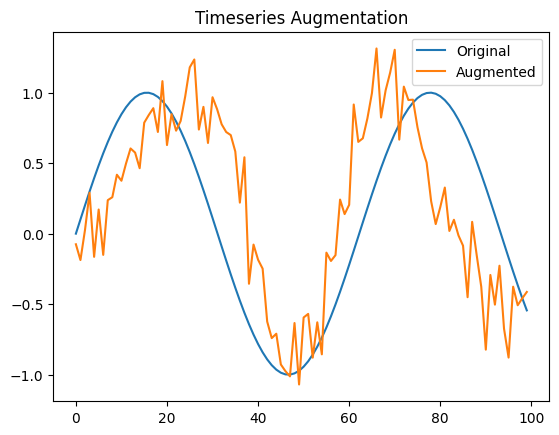

In [27]:
# -----------------------------
# ⏳ TIMESERIES (tsaug)
# -----------------------------
from tsaug import TimeWarp, AddNoise

timeseries = np.sin(np.linspace(0, 10, 100)).reshape(1, -1, 1)
aug = (TimeWarp() * 2) + AddNoise(scale=0.1)
timeseries_aug = aug.augment(timeseries)

plt.plot(timeseries[0], label="Original")
plt.plot(timeseries_aug[0], label="Augmented")
plt.legend()
plt.title("Timeseries Augmentation")
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

def generate_time_series(n, l):
    t = np.linspace(0, 10, l)
    f = np.random.uniform(0.5, 2, n)
    a = np.random.uniform(0.5, 1, n)
    p = np.random.uniform(0, 2*np.pi, n)
    return a[:, None] * np.sin(2*np.pi*f[:, None]*t + p[:, None])

def jitter(data, sigma=0.05):
    return data + np.random.normal(0, sigma, data.shape)

data = generate_time_series(1000, 50)
labels = np.random.randint(0, 2, 1000)
data_aug = jitter(data)
X_train, X_test, y_train, y_test = train_test_split(data_aug, labels, test_size=0.2, random_state=42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=3)
print("Timeseries Accuracy:", model.evaluate(X_test, y_test)[1])

Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5036 - loss: 0.7054
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5518 - loss: 0.6944 
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5655 - loss: 0.6892 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4549 - loss: 0.7224  
Timeseries Accuracy: 0.4749999940395355



# SPEECH AUGMENTATION (torchaudio)


In [30]:
import torchaudio
import torch
waveform = torch.randn(1, 16000)
augment = torch.nn.Sequential(
    torchaudio.transforms.Vol(gain=5.0, gain_type='db'),
    torchaudio.transforms.FrequencyMasking(freq_mask_param=15),
    torchaudio.transforms.TimeMasking(time_mask_param=35)
)
augmented = augment(waveform)
print("Applied audio augmentation with Frequency and Time masking")

Applied audio augmentation with Frequency and Time masking


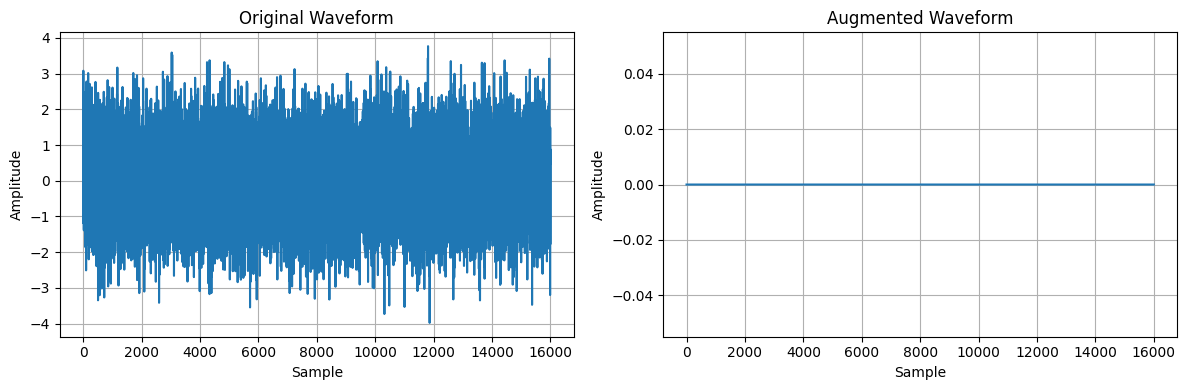

Applied audio augmentation with Frequency and Time masking


In [32]:
import torchaudio
import torch
import matplotlib.pyplot as plt

waveform = torch.randn(1, 16000)
augment = torch.nn.Sequential(
    torchaudio.transforms.Vol(gain=5.0, gain_type='db'),
    torchaudio.transforms.FrequencyMasking(freq_mask_param=15),
    torchaudio.transforms.TimeMasking(time_mask_param=35)
)
augmented = augment(waveform)

# Visual comparison of waveforms
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(waveform[0].numpy())
plt.title("Original Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(augmented[0].numpy())
plt.title("Augmented Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()
print("Applied audio augmentation with Frequency and Time masking")

# DOCUMENT IMAGE (AugLy)

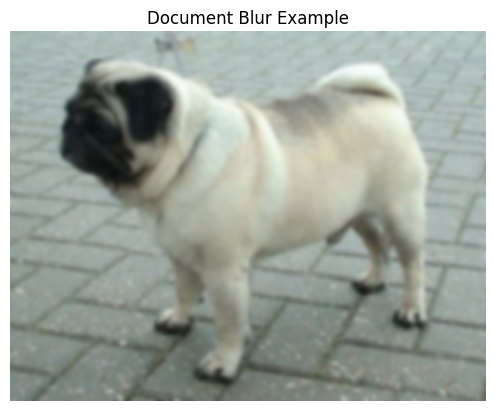


✅ All domain-specific augmentations completed.


In [33]:
# -----------------------------
# 📄 DOCUMENT IMAGE (AugLy)
# -----------------------------
aug_img_doc = imaugs.Blur()(img)
plt.imshow(aug_img_doc)
plt.title("Document Blur Example")
plt.axis("off")
plt.show()

print("\n✅ All domain-specific augmentations completed.")

  A.Affine(rotate=(-15, 15), shear=(-5, 5), mode=1, p=0.3),



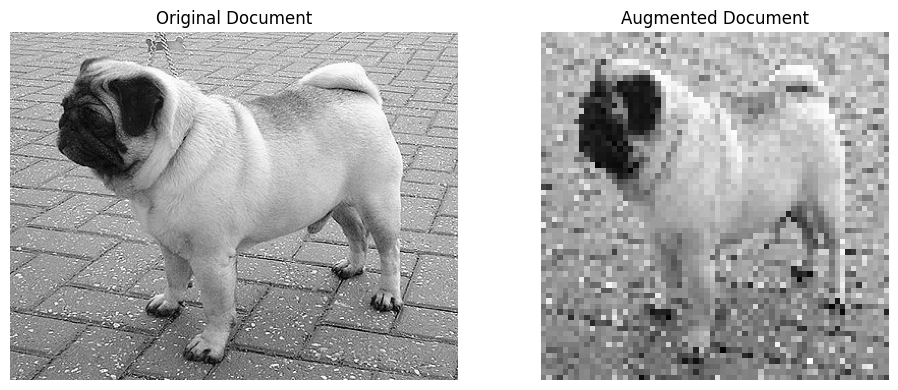


✅ All domain-specific augmentations completed.


In [35]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
img = np.array(image.convert("L"))

doc_transforms = A.Compose([
    A.Resize(64, 64),
    A.OneOf([
        A.MotionBlur(p=0.3),
        A.RandomBrightnessContrast(p=0.3),
        A.Affine(rotate=(-15, 15), shear=(-5, 5), mode=1, p=0.3),
    ], p=0.8),
    A.Normalize(mean=(0.5,), std=(0.5,))
])

aug_img_doc = doc_transforms(image=img)["image"]

# Show comparison
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Document")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(aug_img_doc, cmap='gray')
plt.title("Augmented Document")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\n✅ All domain-specific augmentations completed.")